# EfficientNet-B3 Model for Retinal OCT Disease Classification

This notebook implements an EfficientNet-B3 model for multiclass classification of retinal OCT images from the Kermany2018 dataset.

EfficientNet-B3 is selected as an efficient convolutional neural network because it uses compound scaling to balance network depth, width, and input resolution. The goal of this experiment is to compare its predictive performance, convergence behavior, and computational cost against the ResNet-50 baseline model.

The model is trained using transfer learning with ImageNet pretrained weights, image resizing to 224×224 pixels, data augmentation, early stopping, model checkpointing, and evaluation metrics such as accuracy, precision, recall, F1-score, Macro F1-score, and a confusion matrix.

In [5]:
import os
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

print("TensorFlow version:", tf.__version__)
print("GPUs disponibles:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.19.0
GPUs disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [6]:
DATA_DIR = "/kaggle/input/datasets/fabrizioravelli/retinal-oct-images-splitted"

train_dir = os.path.join(DATA_DIR, "training", "train")
val_dir = os.path.join(DATA_DIR, "training", "val")
test_dir = os.path.join(DATA_DIR, "test")

print("Train existe:", os.path.exists(train_dir))
print("Val existe:", os.path.exists(val_dir))
print("Test existe:", os.path.exists(test_dir))

print("Clases:", os.listdir(train_dir))

Train existe: True
Val existe: True
Test existe: True
Clases: ['DRUSEN', 'CNV', 'NORMAL', 'DME']


In [7]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
EPOCHS = 20

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

print("Clases detectadas:", class_names)
print("Número de clases:", NUM_CLASSES)

Found 61284 files belonging to 4 classes.
Found 7659 files belonging to 4 classes.
Found 7664 files belonging to 4 classes.
Clases detectadas: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Número de clases: 4


In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [11]:
small_train_ds = train_ds.take(20)
small_val_ds = val_ds.take(5)

print("Small train batches:", len(list(small_train_ds)))
print("Small val batches:", len(list(small_val_ds)))

Small train batches: 20
Small val batches: 5


In [12]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
], name="data_augmentation")

In [13]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

efficientnetb3_model = models.Model(inputs, outputs, name="EfficientNetB3_Kermany2018")

efficientnetb3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

efficientnetb3_model.summary()

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB3_Kermany2018"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         6,148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [14]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="efficientnetb3_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger("efficientnetb3_training_log.csv")
]

## Quick Test

In [15]:
start_time = time.time()

history_small = efficientnetb3_model.fit(
    small_train_ds,
    validation_data=small_val_ds,
    epochs=3,
    callbacks=callbacks
)

end_time = time.time()
small_training_time = end_time - start_time

print(f"Tiempo de prueba rápida: {small_training_time:.2f} segundos")

Epoch 1/3


E0000 00:00:1780441015.471024     112 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB3_Kermany2018_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1780441018.404382     170 cuda_dnn.cc:529] Loaded cuDNN version 91002


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2869 - loss: 1.4418
Epoch 1: val_loss improved from None to 0.99451, saving model to efficientnetb3_best_model.keras

Epoch 1: finished saving model to efficientnetb3_best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 28s 489ms/step - accuracy: 0.2937 - loss: 1.4284 - val_accuracy: 0.6625 - val_loss: 0.9945
Epoch 2/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.3658 - loss: 1.3316
Epoch 2: val_loss improved from 0.99451 to 0.87430, saving model to efficientnetb3_best_model.keras

Epoch 2: finished saving model to efficientnetb3_best_model.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 226ms/step - accuracy: 0.4000 - loss: 1.3048 - val_accuracy: 0.7500 - val_loss: 0.8743
Epoch 3/3
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5093 - loss: 1.2340
Epoch 3: val_loss improved from 0.87430 to 0.77174, saving model to efficientnetb3_best_model.keras

Epoch 3: finished saving model to efficientnetb3_best_model.keras
20/20 ━━━━━━━━━━━━━━━━

In [16]:
base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

efficientnetb3_model = models.Model(inputs, outputs, name="EfficientNetB3_Kermany2018")

efficientnetb3_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath="efficientnetb3_best_model.keras",
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    CSVLogger("efficientnetb3_training_log.csv")
]

## Formal Training

In [18]:
start_time = time.time()

history = efficientnetb3_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

end_time = time.time()
training_time = end_time - start_time

print(f"Tiempo total de entrenamiento: {training_time:.2f} segundos")
print(f"Tiempo total de entrenamiento: {training_time/60:.2f} minutos")

Epoch 1/20


E0000 00:00:1780441076.214673     112 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB3_Kermany2018_1/efficientnetb3_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1916/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.6105 - loss: 0.9868
Epoch 1: val_loss improved from None to 0.53348, saving model to efficientnetb3_best_model.keras

Epoch 1: finished saving model to efficientnetb3_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 319s 159ms/step - accuracy: 0.7052 - loss: 0.7980 - val_accuracy: 0.8180 - val_loss: 0.5335
Epoch 2/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.7817 - loss: 0.6050
Epoch 2: val_loss improved from 0.53348 to 0.46753, saving model to efficientnetb3_best_model.keras

Epoch 2: finished saving model to efficientnetb3_best_model.keras
1916/1916 ━━━━━━━━━━━━━━━━━━━━ 306s 160ms/step - accuracy: 0.7904 - loss: 0.5848 - val_accuracy: 0.8397 - val_loss: 0.4675
Epoch 3/20
1915/1916 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 0.8038 - loss: 0.5481
Epoch 3: val_loss improved from 0.46753 to 0.43678, saving model to efficientnetb3_best_model.keras

Epoch 3: finished saving model to efficientnetb3_best_model.ker

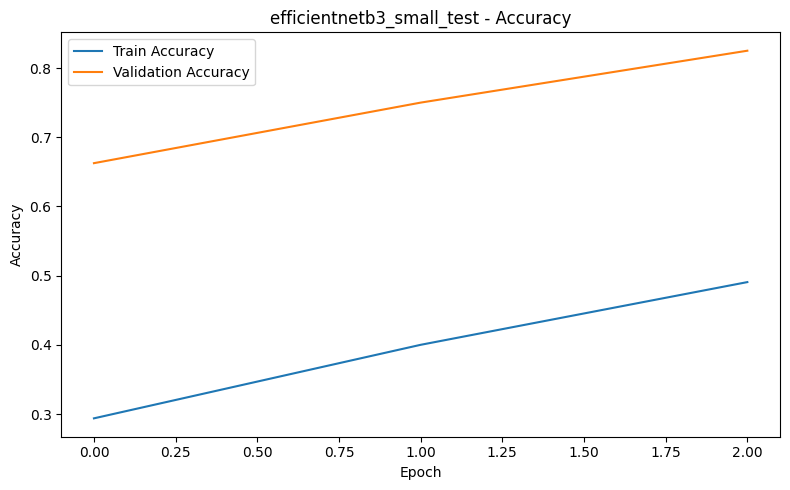

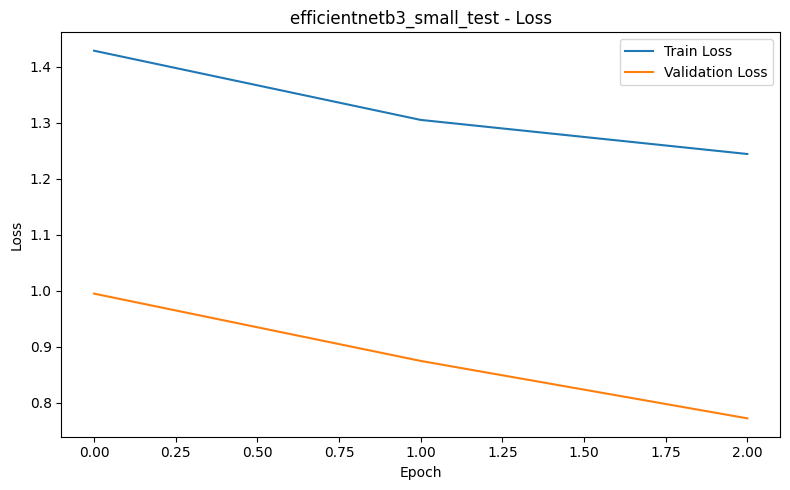

In [21]:
def plot_training_curves(history, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_accuracy_curve.png", dpi=300)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{model_name} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{model_name}_loss_curve.png", dpi=300)
    plt.show()

plot_training_curves(history_small, "efficientnetb3_small_test")

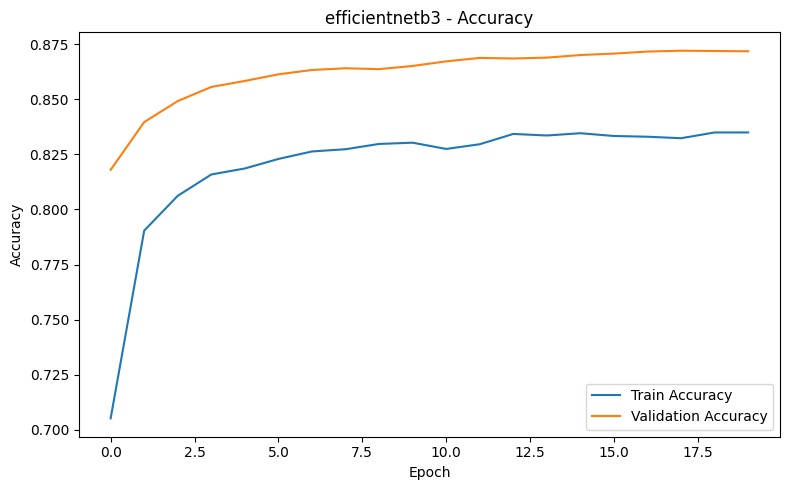

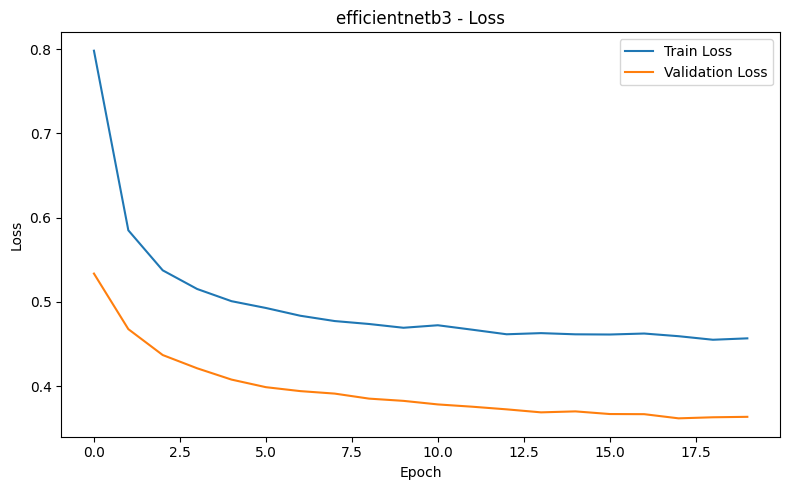

In [22]:
  plot_training_curves(history, "efficientnetb3")

In [23]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = efficientnetb3_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [24]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report.to_csv("efficientnetb3_classification_report.csv")

df_report

,precision,recall,f1-score,support
CNV,0.880190,0.937757,0.908062,3165.000000
DME,0.858921,0.753412,0.802714,1099.000000
DRUSEN,0.732240,0.513410,0.603604,783.000000
NORMAL,0.899964,0.955674,0.926983,2617.000000
accuracy,0.874087,0.874087,0.874087,0.874087
macro avg,0.842829,0.790063,0.810341,7664.000000
weighted avg,0.868777,0.874087,0.868311,7664.000000


In [25]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

         CNV       0.88      0.94      0.91      3165
         DME       0.86      0.75      0.80      1099
      DRUSEN       0.73      0.51      0.60       783
      NORMAL       0.90      0.96      0.93      2617

    accuracy                           0.87      7664
   macro avg       0.84      0.79      0.81      7664
weighted avg       0.87      0.87      0.87      7664



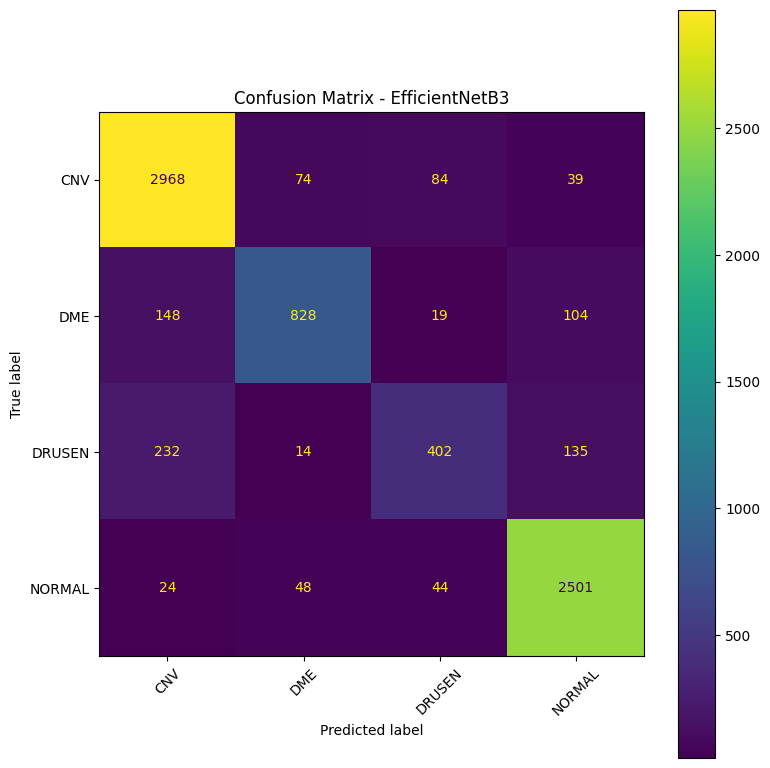

In [26]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix - EfficientNetB3")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("efficientnetb3_confusion_matrix.png", dpi=300)
plt.show()

In [27]:
metrics = {
    "model": "EfficientNetB3",
    "accuracy": accuracy_score(y_true, y_pred),
    "precision_macro": precision_score(y_true, y_pred, average="macro"),
    "recall_macro": recall_score(y_true, y_pred, average="macro"),
    "f1_macro": f1_score(y_true, y_pred, average="macro"),
    "precision_weighted": precision_score(y_true, y_pred, average="weighted"),
    "recall_weighted": recall_score(y_true, y_pred, average="weighted"),
    "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
    "training_time_seconds": training_time,
    "training_time_minutes": training_time / 60,
    "epochs_trained": len(history.history["loss"])
}

df_metrics = pd.DataFrame([metrics])
df_metrics.to_csv("efficientnetb3_metrics_summary.csv", index=False)

df_metrics

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,training_time_seconds,training_time_minutes,epochs_trained
0,EfficientNetB3,0.874087,0.842829,0.790063,0.810341,0.868777,0.874087,0.868311,6139.241065,102.320684,20


In [28]:
total_params = efficientnetb3_model.count_params()

trainable_params = np.sum([
    np.prod(v.shape) for v in efficientnetb3_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape) for v in efficientnetb3_model.non_trainable_weights
])

params_summary = pd.DataFrame([{
    "model": "EfficientNetB3",
    "total_params": total_params,
    "trainable_params": trainable_params,
    "non_trainable_params": non_trainable_params
}])

params_summary.to_csv("efficientnetb3_params_summary.csv", index=False)
params_summary

,model,total_params,trainable_params,non_trainable_params
0,EfficientNetB3,10789683,6148,10783535.0


## Preliminary Conclusion

EfficientNet-B3 was implemented as the second convolutional neural network for retinal OCT disease classification. This model was selected because of its efficient compound scaling strategy, which balances depth, width, and resolution.

The model was trained using transfer learning, data augmentation, early stopping, and checkpointing. Its performance will be compared against the ResNet-50 baseline and the Vision Transformer model using accuracy, precision, recall, F1-score, Macro F1-score, training time, number of parameters, and confusion matrix analysis.

This experiment will help determine whether EfficientNet-B3 provides a better balance between predictive performance and computational cost for retinal disease classification.